# Day 2 - 세션 2 : 모델 해석과 성능 개선

## 📌 세션 1 복습

세션 1에서는 PyCaret의 `setup()` → `compare_models()`로 콘크리트 압축강도를 예측하는
**최적 모델(LightGBM)**을 찾았습니다. (R² ≈ 0.92, RMSE ≈ 4.6 MPa)

## 🎯 세션 2의 목표

"가장 정확한 모델을 찾았다"는 끝이 아니라 시작입니다. 현장에서는 다음 두 가지 질문이 항상 따라옵니다.

1. **"왜 그렇게 예측했는가?"** - 모델이 어떤 변수를 보고 그런 숫자를 냈는지 설명할 수 있는가
2. **"더 잘할 수 있는가?"** - 지금 성능에서 추가로 개선할 여지가 있는가

이번 세션에서는 이 두 질문에 PyCaret이 어떻게 답하는지 살펴봅니다.

## ✅ 세션 2 목표

1. "블랙박스 모델" 문제가 현장에서 왜 중요한지 이해한다
2. `interpret_model()`로 변수 중요도(SHAP) 그래프를 그리고 해석한다
3. `tune_model()`로 하이퍼파라미터를 자동 튜닝하고, 튜닝 전후 성능을 비교한다


## STEP 1. 이전 세션 재현하기

새 노트북이므로, 세션 1에서 했던 데이터 로드 → `setup()` → `compare_models()`를 다시 실행해서
`best_model`을 준비합니다. (앞서 본 것과 동일한 코드입니다.)


In [ ]:
import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 설정 (OS별 한글 폰트 자동 설정)
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("concrete_data.csv")
df.columns = df.columns.str.strip()

from pycaret.regression import *

s = setup(data=df, target='concrete_compressive_strength', session_id=123)
best_model = compare_models()
base_results = pull()

print("최적 모델:", best_model)
base_results[['Model', 'MAE', 'RMSE', 'R2', 'TT (Sec)']].head(1)

## STEP 2. 블랙박스 문제 - "모델이 왜 그렇게 예측했을까?"

세션 1에서 가장 성능이 좋았던 모델은 **LightGBM**(트리 기반 모델)입니다. 정확도는 높지만,
내부적으로 수백 개의 작은 의사결정나무(decision tree)를 조합해서 예측값을 만들기 때문에
사람이 "왜 38 MPa로 예측했는지"를 직관적으로 설명하기 어렵습니다.

### 🏭 현장에서 문제가 되는 순간

> "이 배합으로 만들면 38 MPa라고 하는데... 왜요? 어떤 재료를 더 넣어야 강도가 올라가나요?"

담당자가 이 질문에 답하지 못하면, 아무리 정확한 모델이라도 **현장에서 신뢰받지 못하고 사용되지 않습니다.**

### 💡 PyCaret의 해답 - `interpret_model()`

PyCaret은 **SHAP(SHapley Additive exPlanations)**이라는 기법을 이용해,
"각 변수가 예측값에 얼마나, 어떤 방향으로 기여했는지"를 한 줄 코드로 시각화해줍니다.


## STEP 3. 변수 중요도(SHAP) 그래프 읽는 법

`interpret_model(best_model)`을 실행하면 아래와 같은 **SHAP Summary Plot**이 그려집니다.

### 그래프 구조

- **y축**: 변수 이름 - 위에 있을수록 예측에 미치는 영향이 큰 변수
- **x축 (SHAP value)**: 그 변수가 예측값을 **얼마나, 어느 방향으로** 바꿨는지
  - 오른쪽(양수) = 압축강도를 **높이는** 방향으로 기여
  - 왼쪽(음수) = 압축강도를 **낮추는** 방향으로 기여
- **점의 색**: 해당 변수의 **실제 값** (빨강 = 값이 큼, 파랑 = 값이 작음)

### 콘크리트 데이터 해석 예시

| 변수 | 그래프에서 보이는 패턴 | 현장 의미 |
|---|---|---|
| `age` (양생 기간) | 빨간 점(양생 오래함)이 오른쪽에 많음 | 오래 양생할수록 강도 ↑ |
| `cement` (시멘트량) | 빨간 점이 오른쪽에 많음 | 시멘트 많을수록 강도 ↑ |
| `water` (물) | 빨간 점(물 많음)이 왼쪽에 많음 | 물 많을수록 강도 ↓ |

이제 직접 그려서 확인해봅시다. (실행에 10~20초 정도 걸릴 수 있습니다.)


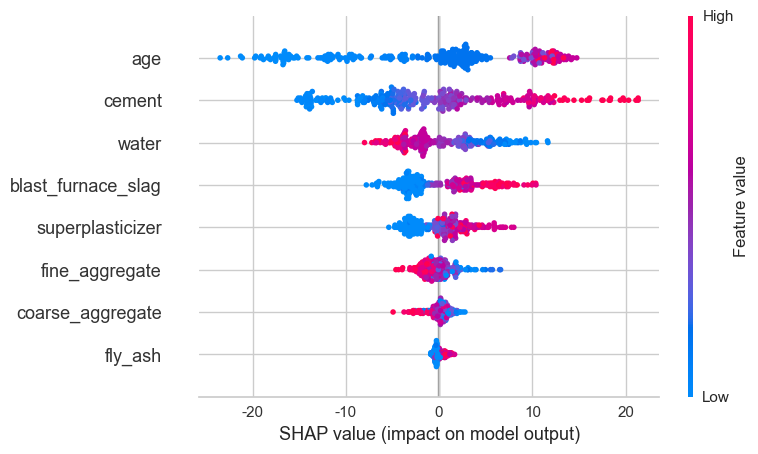

In [2]:
interpret_model(best_model)

## STEP 4. 해석 결과를 현장 질문으로 연결하기

SHAP 그래프를 보면 대체로 **`age`(양생 기간)와 `cement`(시멘트량)가 강도에 가장 큰 양의 영향**을,
**`water`(물)가 가장 큰 음의 영향**을 주는 것을 확인할 수 있습니다.

### 🤔 토론해보기

- "양생 기간을 7일 더 늘리면 강도가 얼마나 달라질까?" - 이 그래프만으로 답할 수 있을까요, 아니면 추가 분석이 필요할까요?
- "물-시멘트 비율을 낮추면 강도에 어떤 효과가 있을까?" - 그래프의 `water`, `cement` 패턴이 이 질문에 어떤 근거를 주나요?
- 이 그래프를 **배합 설계 담당자**에게 보여준다면, 어떤 식으로 설명하는 게 좋을까요?

👉 핵심은, AI가 "정답"만 주는 게 아니라 **"왜 그런 정답이 나왔는지에 대한 근거"**까지 함께 제공한다는 점입니다.
이 근거가 있어야 현장에서 AI의 제안을 신뢰하고 실제 배합 설계에 참고할 수 있습니다.


## STEP 5. 성능 더 끌어올리기 - 하이퍼파라미터 튜닝

### 하이퍼파라미터란?

모델이 데이터로부터 "학습"하는 값(가중치 등)이 아니라, **학습을 시작하기 전에 사람이 미리 설정해야 하는 값**입니다.

예) LightGBM의 경우 - 트리의 개수, 트리의 최대 깊이, 학습률(learning rate) 등

이 값들을 어떻게 설정하느냐에 따라 같은 모델이라도 성능이 달라집니다.

### 📷 비유 - 카메라 설정

- **튜닝 전**: 새 카메라를 사서 기본(자동) 설정 그대로 사용
- **튜닝 후**: 촬영 환경(조명, 거리 등)에 맞게 조리개·셔터스피드를 최적으로 조정

같은 카메라(모델)인데, 설정을 맞추면 결과물(사진/예측 성능)이 달라집니다.

### 💡 PyCaret의 해답 - `tune_model()`

`tune_model()` 한 줄로, 수십~수백 가지의 하이퍼파라미터 조합을 자동으로 시도해보고
**교차검증 성능이 가장 좋은 조합**을 찾아 적용한 모델을 반환합니다.

`n_iter`는 몇 가지 조합을 시도할지 정하는 값입니다 (값이 클수록 더 꼼꼼히 탐색하지만 시간이 더 걸립니다).


In [3]:
tuned_model = tune_model(best_model, n_iter=30, optimize='R2')
tuned_results = pull()

tuned_results.tail(2)[['MAE', 'RMSE', 'R2']]

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.8208,18.3020,4.2781,0.9279,0.1113,0.0855
1,3.6682,24.8109,4.9811,0.9269,0.1533,0.1193
2,3.0836,16.3088,4.0384,0.9347,0.1572,0.1077
3,3.2191,18.0475,4.2482,0.9485,0.1645,0.1218
4,3.1705,21.1350,4.5973,0.9301,0.1771,0.1249
5,3.7522,28.9140,5.3772,0.9059,0.1841,0.1354
6,3.3142,21.0186,4.5846,0.9207,0.1565,0.1103
7,2.9963,16.9596,4.1182,0.9345,0.1602,0.1168
8,2.7919,12.9184,3.5942,0.9382,0.1095,0.0893


Fitting 10 folds for each of 30 candidates, totalling 300 fits


,MAE,RMSE,R2
Fold,,,
Mean,3.2875,4.5330,0.9255
Std,0.3954,0.5765,0.0166


## STEP 6. 튜닝 전후 비교

아래 표에서 튜닝 전(`best_model`)과 튜닝 후(`tuned_model`)의 교차검증 평균 성능을 나란히 비교합니다.

### ⚠️ 튜닝이 항상 큰 차이를 만드는 건 아닙니다

이번 실행에서는 R²가 약 **0.9215 → 0.925x** 수준, RMSE가 약 **4.64 → 4.5x MPa** 수준으로 소폭 개선되는 것을 볼 수 있습니다.
(데이터셋의 난수 시드나 `n_iter` 값에 따라 결과가 조금씩 달라질 수 있습니다.)

이미 `compare_models()`에서 좋은 모델이 선택되었다면, 튜닝으로 얻는 추가 개선은 **크지 않을 수도 있습니다.**
그래도 "추가로 시도해볼 만한 한 줄"이라는 점에서 실무적으로 의미가 있습니다.


In [4]:
before = base_results[['MAE', 'RMSE', 'R2']].iloc[0]
after = tuned_results.loc['Mean', ['MAE', 'RMSE', 'R2']]

compare_df = pd.DataFrame({'튜닝 전': before, '튜닝 후': after})
compare_df

,튜닝 전,튜닝 후
MAE,3.2006,3.2875
RMSE,4.6356,4.5330
R2,0.9215,0.9255


## STEP 7. 실습 - 특정 변수에 집중해서 해석하기

`interpret_model()`은 전체 변수의 영향을 한눈에 보여주는 `'summary'` 플롯 외에도,
**`plot='correlation'`** 옵션과 `feature` 인자를 함께 쓰면 **특정 변수 하나**가
예측값에 미치는 영향을 더 자세히 볼 수 있습니다.

세션 1 STEP 3에서 `age`(양생 기간)가 압축강도와 상관관계가 가장 큰 변수 중 하나였습니다.
이번엔 `age`를 지정해서, 양생 기간이 길어질수록 SHAP 값(예측에 대한 기여도)이 어떻게 변하는지 확인해봅시다.


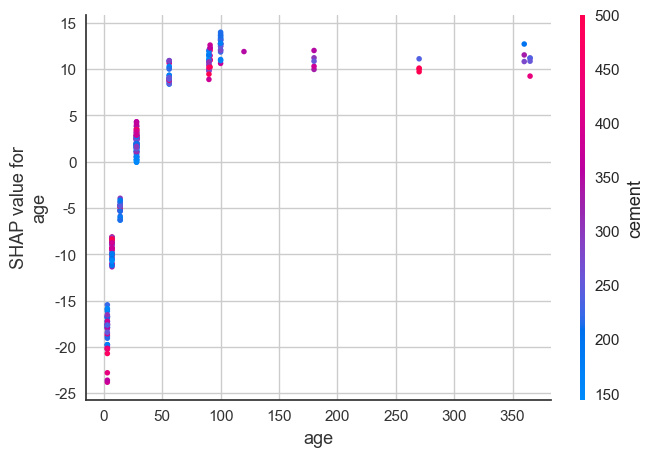

In [5]:
interpret_model(tuned_model, plot='correlation', feature='age')

## 📝 세션 2 정리

```
세션 1에서 찾은 최적 모델 (LightGBM)
            ↓
interpret_model() → SHAP 그래프
            ↓
"age(양생기간)와 cement(시멘트량)가 강도에 가장 큰 영향"
            ↓
tune_model() → 하이퍼파라미터 자동 튜닝
            ↓
변수 중요도 그래프 + 튜닝 완료 모델 ✅
```

### ✅ 산출물

- 변수 중요도(SHAP) 그래프와 그 해석
- 튜닝 전/후 성능 비교표, 튜닝된 모델(`tuned_model`)

### 🔮 다음 세션 예고

지금까지는 모델이 Jupyter Notebook 안에서만 존재했습니다.
세션 3에서는 이 모델을 **누구나 웹 브라우저에서 사용해볼 수 있는 간단한 앱(Gradio)**으로 만들어봅니다.
